# Pet Finder - Adopción de Mascotas

PetFinder.es una plataforma de adopción de Mascotas de Malasia, con una base de datos de más de 150.000 animales. 

Las tasas de adopción de animales están fuertemente correlacionadas con los metadatos asociados con sus perfiles en línea, como el texto descriptivo y las características de las fotografías. Como ejemplo, PetFinder está experimentando actualmente con una herramienta de inteligencia artificial simple llamada Cuteness Meter, que clasifica qué tan linda es una mascota en función de las cualidades presentes en sus fotos.

En esta competencia, desarrollará algoritmos para predecir la adoptabilidad de las mascotas, específicamente, ¿qué tan rápido se adopta una mascota?

Web Organización: https://www.petfinder.my/

Datos: https://www.kaggle.com/c/petfinder-adoption-prediction



## Análisis Exploratorio

En este trabajo se busca predecir la velocidad a la que se adopta una mascota, según la lista de la mascota en PetFinder. 

A veces, un perfil representa a un grupo de mascotas. En este caso, la velocidad de adopción está determinada por la velocidad a la que se adoptan todas las mascotas. 

Los datos incluyen datos de **Texto Libre**, **Datos Tabulares** e **Emágenes**, lo que lo hace un dataset sumamente rico para explorar

File descriptions:

* all_data.csv - Tabular/text data for the all_dataing set
* test.csv - Tabular/text data for the test set
* sample_submission.csv - A sample submission file in the correct format
* breed_labels.csv - Contains Type, and BreedName for each BreedID. Type 1 is dog, 2 is cat.
* color_labels.csv - Contains ColorName for each ColorID
* state_labels.csv - Contains StateName for each StateID

In [276]:
# Importación de Librerías
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 
from wordcloud import WordCloud

%matplotlib inline
pd.set_option('display.max_columns', 30)
plt.rcParams['figure.figsize'] = [12.0, 8.0]

In [277]:
# Datos Tabulares
train = pd.read_csv('../input/petfinder-adoption-prediction/train/train.csv')
test = pd.read_csv('../input/petfinder-adoption-prediction/test/test.csv')
raza = pd.read_csv('../input/petfinder-adoption-prediction/BreedLabels.csv')

In [278]:
# Agregamos columna identificadora
train["dataset_type"] = "train"
test["dataset_type"] = "test"

# Unimos ambos
all_data = pd.concat([train, test], ignore_index=True)

In [279]:
train.shape

(14993, 25)

In [280]:
test.shape

(3972, 24)

In [281]:
train.head() 

,Type,Name,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,FurLength,Vaccinated,Dewormed,Sterilized,Health,Quantity,Fee,State,RescuerID,VideoAmt,Description,PetID,PhotoAmt,AdoptionSpeed,dataset_type
0,2,Nibble,3,299,0,1,1,7,0,1,1,2,2,2,1,1,100,41326,8480853f516546f6cf33aa88cd76c379,0,Nibble is a 3+ month old ball of cuteness. He ...,86e1089a3,1.0,2,train
1,2,No Name Yet,1,265,0,1,1,2,0,2,2,3,3,3,1,1,0,41401,3082c7125d8fb66f7dd4bff4192c8b14,0,I just found it alone yesterday near my apartm...,6296e909a,2.0,0,train
2,1,Brisco,1,307,0,1,2,7,0,2,2,1,1,2,1,1,0,41326,fa90fa5b1ee11c86938398b60abc32cb,0,Their pregnant mother was dumped by her irresp...,3422e4906,7.0,3,train
3,1,Miko,4,307,0,2,1,2,0,2,1,1,1,2,1,1,150,41401,9238e4f44c71a75282e62f7136c6b240,0,"Good guard dog, very alert, active, obedience ...",5842f1ff5,8.0,2,train
4,1,Hunter,1,307,0,1,1,0,0,2,1,2,2,2,1,1,0,41326,95481e953f8aed9ec3d16fc4509537e8,0,This handsome yet cute boy is up for adoption....,850a43f90,3.0,2,train


In [282]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14993 entries, 0 to 14992
Data columns (total 25 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Type           14993 non-null  int64  
 1   Name           13728 non-null  object 
 2   Age            14993 non-null  int64  
 3   Breed1         14993 non-null  int64  
 4   Breed2         14993 non-null  int64  
 5   Gender         14993 non-null  int64  
 6   Color1         14993 non-null  int64  
 7   Color2         14993 non-null  int64  
 8   Color3         14993 non-null  int64  
 9   MaturitySize   14993 non-null  int64  
 10  FurLength      14993 non-null  int64  
 11  Vaccinated     14993 non-null  int64  
 12  Dewormed       14993 non-null  int64  
 13  Sterilized     14993 non-null  int64  
 14  Health         14993 non-null  int64  
 15  Quantity       14993 non-null  int64  
 16  Fee            14993 non-null  int64  
 17  State          14993 non-null  int64  
 18  Rescue

### Data Fields

* PetID - Unique hash ID of pet profile
* AdoptionSpeed - Categorical speed of adoption. Lower is faster. This is the value to predict. See below section for more info.
* Type - Type of animal (1 = Dog, 2 = Cat)
* Name - Name of pet (Empty if not named)
* Age - Age of pet when listed, in months
* Breed1 - Primary breed of pet (Refer to BreedLabels dictionary)
* Breed2 - Secondary breed of pet, if pet is of mixed breed (Refer to BreedLabels dictionary)
* Gender - Gender of pet (1 = Male, 2 = Female, 3 = Mixed, if profile represents group of pets)
* Color1 - Color 1 of pet (Refer to ColorLabels dictionary)
* Color2 - Color 2 of pet (Refer to ColorLabels dictionary)
* Color3 - Color 3 of pet (Refer to ColorLabels dictionary)
* MaturitySize - Size at maturity (1 = Small, 2 = Medium, 3 = Large, 4 = Extra Large, 0 = Not Specified)
* FurLength - Fur length (1 = Short, 2 = Medium, 3 = Long, 0 = Not Specified)
* Vaccinated - Pet has been vaccinated (1 = Yes, 2 = No, 3 = Not Sure)
* Dewormed - Pet has been dewormed (1 = Yes, 2 = No, 3 = Not Sure)
* Sterilized - Pet has been spayed / neutered (1 = Yes, 2 = No, 3 = Not Sure)
* Health - Health Condition (1 = Healthy, 2 = Minor Injury, 3 = Serious Injury, 0 = Not Specified)
* Quantity - Number of pets represented in profile
* Fee - Adoption fee (0 = Free)
* State - State location in Malaysia (Refer to StateLabels dictionary)
* RescuerID - Unique hash ID of rescuer
* VideoAmt - Total uploaded videos for this pet
* PhotoAmt - Total uploaded photos for this pet
* Description - Profile write-up for this pet. The primary language used is English, with some in Malay or Chinese.

### Target: AdoptionSpeed
Este valor esta determinado por cuan rapido, si es que lo hay, una mascota es adoptada. Los valores se determinan de la siguiente manera:

* 0 - La mascota fue adoptada el mismo día en que fue publicada.
* 1 - La mascota fue adoptada entre 1 y 7 días (1ra semana) después de ser publicada.
* 2 - La mascota fue adoptada entre 8 y 30 días (1er mes) después de ser publicada.
* 3 - La mascota fue adoptada entre 31 y 90 días (2do y 3er mes) después de ser publicada.
* 4 - No hubo adopción después de 100 días de haber sido publicada. (No hay mascotas en este conjunto de datos que hayan esperado entre 90 y 100 días).

## Hay valores faltantes? 

In [283]:
# Revisar valores nulos en el DataFrame all_data
all_data.isna().sum()

Type                0
Name             1679
Age                 0
Breed1              0
Breed2              0
Gender              0
Color1              0
Color2              0
Color3              0
MaturitySize        0
FurLength           0
Vaccinated          0
Dewormed            0
Sterilized          0
Health              0
Quantity            0
Fee                 0
State               0
RescuerID           0
VideoAmt            0
Description        14
PetID               0
PhotoAmt            0
AdoptionSpeed    3972
dataset_type        0
dtype: int64

In [284]:
all_data.tail()

,Type,Name,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,FurLength,Vaccinated,Dewormed,Sterilized,Health,Quantity,Fee,State,RescuerID,VideoAmt,Description,PetID,PhotoAmt,AdoptionSpeed,dataset_type
18960,1,Hugo,5,307,307,1,1,2,0,2,1,1,1,2,1,2,150,41401,18ec8ca4486bc2760de0bd5390cee30c,0,Found on the streets. Treated for mange. They ...,ae57f8d52,5.0,NaN,test
18961,1,Spot,30,307,307,1,1,2,7,2,1,3,1,2,1,1,0,41326,d83be5f5e2d04e24d7376e99eafd8708,0,Very good guard dog. Healthy was found in Fron...,83432904d,2.0,NaN,test
18962,2,NaN,5,300,0,3,1,2,4,2,2,2,3,2,1,6,0,41401,30aa45fdbe45e39d5614ef583b569073,0,these cat's mother was killed when they was ne...,399013029,1.0,NaN,test
18963,1,Smokey,24,307,0,2,5,7,0,2,2,2,2,2,1,1,0,41325,087903c2819a6297519c93d962b488d5,0,"smokey is good family pet. very obedient,so lo...",fd80b8c80,3.0,NaN,test
18964,2,NaN,1,266,0,3,1,7,0,1,1,3,3,2,1,6,0,41326,041876679ae0261e3ee4aefe9e66316f,0,Found abandoned with the mother at nearby shop...,493ed84ae,1.0,NaN,test


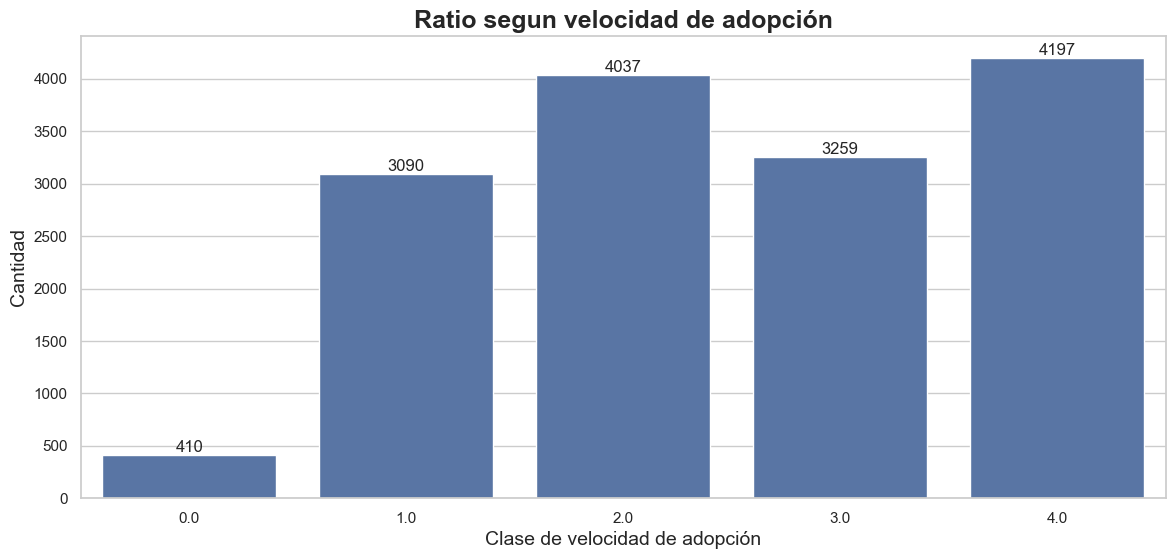

In [285]:
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(14,6))
ax = sns.countplot(
    x='AdoptionSpeed',
    data=all_data,
    legend=False
)

# Etiquetas de conteo arriba de cada barra
for container in ax.containers:
    ax.bar_label(container)

# Títulos y ejes
ax.set_title("Ratio segun velocidad de adopción", fontsize=18, weight='bold')
ax.set_xlabel("Clase de velocidad de adopción", fontsize=14)
ax.set_ylabel("Cantidad", fontsize=14)

plt.show()

In [286]:
# Mapeamos el Tipo de Mascota
all_data['Type'] = all_data['Type'].apply(lambda x: 'Dog' if x == 1 else 'Cat')

## La cantidad de animales en train y test esta bien distribuida? 

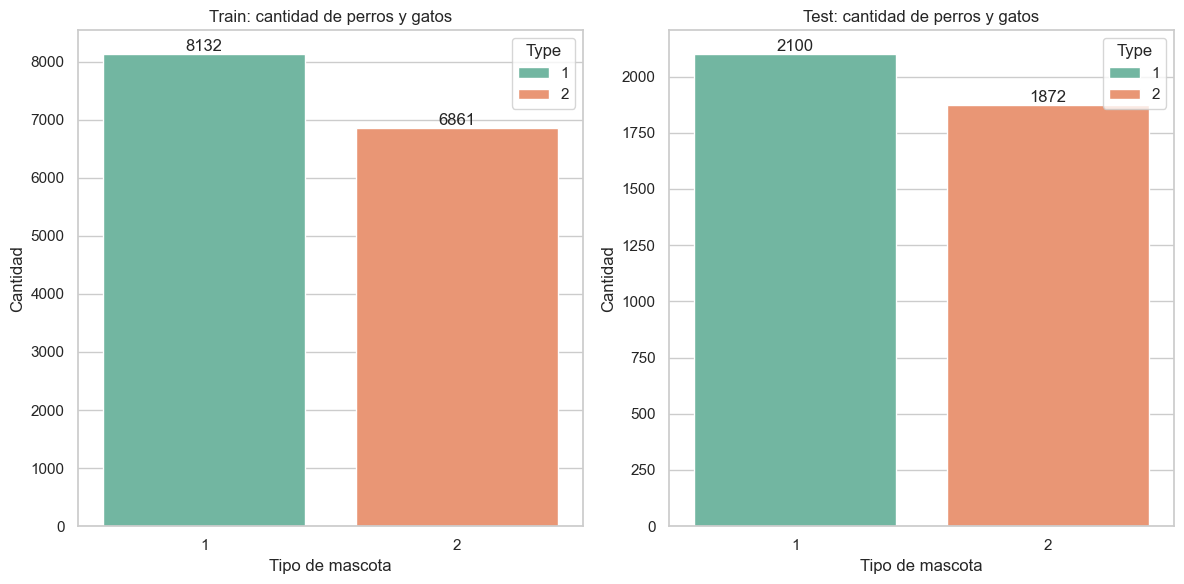

In [287]:
sns.set_theme(style="whitegrid")

fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Train
sns.countplot(
    x='Type',
    hue='Type',
    data=train,
    palette="Set2",
    ax=axs[0]
)
axs[0].set_title("Train: cantidad de perros y gatos")
axs[0].set_xlabel("Tipo de mascota")
axs[0].set_ylabel("Cantidad")
for container in axs[0].containers:
    axs[0].bar_label(container)

# Test
sns.countplot(
    x='Type',
    hue='Type',
    data=test,
    palette="Set2",
    ax=axs[1]
)
axs[1].set_title("Test: cantidad de perros y gatos")
axs[1].set_xlabel("Tipo de mascota")
axs[1].set_ylabel("Cantidad")
for container in axs[1].containers:
    axs[1].bar_label(container)

plt.tight_layout()
plt.show()


## Velocidad de adopción según tipo de mascota

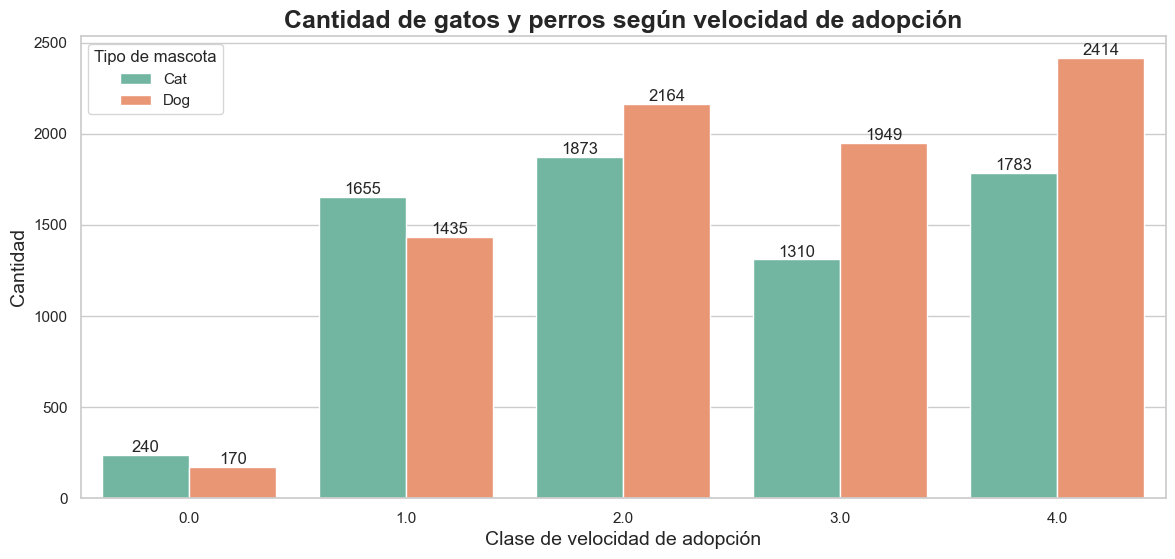

In [288]:
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(14,6))
ax = sns.countplot(
    x='AdoptionSpeed',
    data=all_data,
    hue='Type',       # ahora comparamos Cat vs Dog
    palette="Set2"
)

# Etiquetas de conteo arriba de cada barra
for container in ax.containers:
    ax.bar_label(container)

# Títulos y ejes
ax.set_title("Cantidad de gatos y perros según velocidad de adopción", fontsize=18, weight='bold')
ax.set_xlabel("Clase de velocidad de adopción", fontsize=14)
ax.set_ylabel("Cantidad", fontsize=14)

plt.legend(title="Tipo de mascota")
plt.show()

## Nube de palabras con los nombres de las mascotas

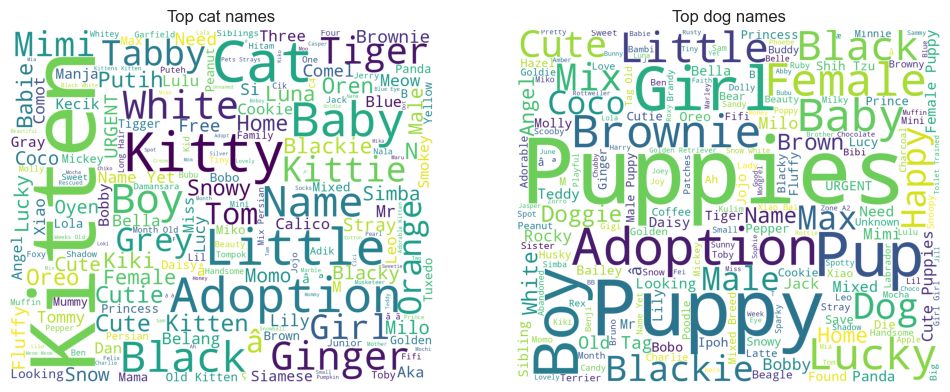

In [289]:
plt.subplot(1, 2, 1)
text_cat = ' '.join(all_data.loc[all_data['Type'] == 'Cat', 'Name'].fillna('').values)
wordcloud = WordCloud(max_font_size=None, background_color='white',
                      width=1200, height=1000).generate(text_cat)
plt.imshow(wordcloud)
plt.title('Top cat names')
plt.axis("off")

plt.subplot(1, 2, 2)
text_dog = ' '.join(all_data.loc[all_data['Type'] == 'Dog', 'Name'].fillna('').values)
wordcloud = WordCloud(max_font_size=None, background_color='white',
                      width=1200, height=1000).generate(text_dog)
plt.imshow(wordcloud)
plt.title('Top dog names')
plt.axis("off")

plt.show()

In [290]:
# Lista de nombres genéricos que NO consideramos verdaderos nombres
nombres_invalidos = ['Unnamed', 'No name', 'No Name Yet', 'Urgent', 'Lost Dog']

# Rellenamos nulos
all_data['Name'] = all_data['Name'].fillna('Unnamed')

# Identificamos si contienen dígitos
contiene_numeros = all_data['Name'].str.contains(r'\d', regex=True)

# Extension del nombre
extension = (all_data['Name'].str.len() <= 3) | (all_data['Name'].str.len() > 15)

# Creamos la columna Has_name: 1 si no es inválido y no contiene números
all_data['Has_name'] = (~all_data['Name'].isin(nombres_invalidos) & ~contiene_numeros & ~extension).astype(int)


In [291]:
all_data.head()

,Type,Name,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,FurLength,Vaccinated,Dewormed,Sterilized,Health,Quantity,Fee,State,RescuerID,VideoAmt,Description,PetID,PhotoAmt,AdoptionSpeed,dataset_type,Has_name
0,Cat,Nibble,3,299,0,1,1,7,0,1,1,2,2,2,1,1,100,41326,8480853f516546f6cf33aa88cd76c379,0,Nibble is a 3+ month old ball of cuteness. He ...,86e1089a3,1.0,2.0,train,1
1,Cat,No Name Yet,1,265,0,1,1,2,0,2,2,3,3,3,1,1,0,41401,3082c7125d8fb66f7dd4bff4192c8b14,0,I just found it alone yesterday near my apartm...,6296e909a,2.0,0.0,train,0
2,Dog,Brisco,1,307,0,1,2,7,0,2,2,1,1,2,1,1,0,41326,fa90fa5b1ee11c86938398b60abc32cb,0,Their pregnant mother was dumped by her irresp...,3422e4906,7.0,3.0,train,1
3,Dog,Miko,4,307,0,2,1,2,0,2,1,1,1,2,1,1,150,41401,9238e4f44c71a75282e62f7136c6b240,0,"Good guard dog, very alert, active, obedience ...",5842f1ff5,8.0,2.0,train,1
4,Dog,Hunter,1,307,0,1,1,0,0,2,1,2,2,2,1,1,0,41326,95481e953f8aed9ec3d16fc4509537e8,0,This handsome yet cute boy is up for adoption....,850a43f90,3.0,2.0,train,1


## Tener nombre impacta en la velocidad de adopción?

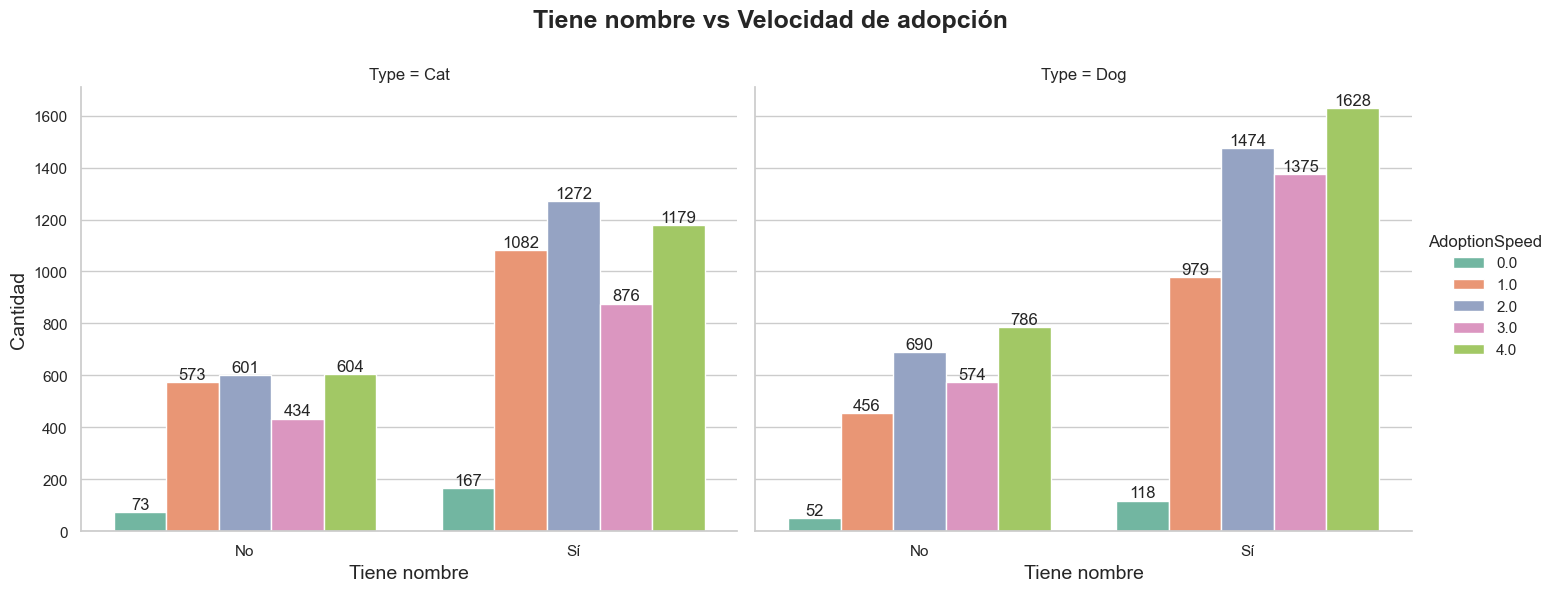

In [292]:
sns.set_theme(style="whitegrid")

g = sns.catplot(
    data=all_data,
    x='Has_name',
    hue='AdoptionSpeed',
    col='Type',           # 1 subplot para Dogs y 1 para Cats
    kind='count',
    palette="Set2",
    height=6, aspect=1.2
)

# Personalización de ejes
for ax in g.axes.flat:
    # etiquetas de X
    ax.set_xticks(range(2))
    ax.set_xticklabels(['No', 'Sí'])
    ax.set_xlabel("Tiene nombre", fontsize=14)
    ax.set_ylabel("Cantidad", fontsize=14)
    
    # etiquetas de conteo encima de cada barra
    for container in ax.containers:
        ax.bar_label(container)

# Título general
g.fig.suptitle("Tiene nombre vs Velocidad de adopción", fontsize=18, weight='bold')
plt.subplots_adjust(top=0.85)

plt.show()


## Edad de las mascotas

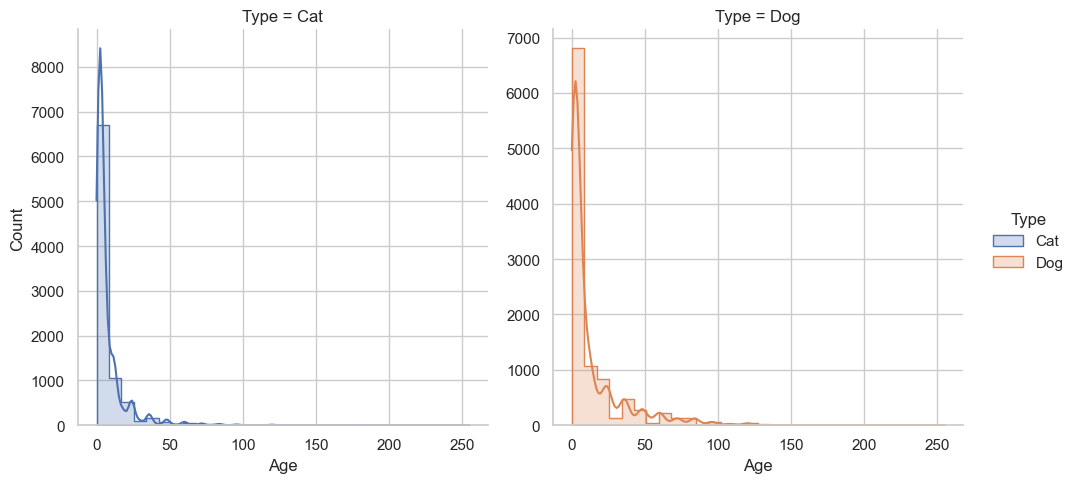

In [293]:
sns.set_theme(style="whitegrid")

sns.displot(
    data=all_data,
    x="Age",
    bins=30,
    kde=True,       # agrega curva de densidad
    hue="Type",     # colorea por especie (ej: Cat/Dog)
    element="step", # hace que las barras sean transparentes con contorno
    col="Type",     # separa en columnas por especie
    facet_kws={'sharey': False, 'sharex': True}  # cada subplot maneja su escala en Y
)

plt.show()

## Grupos etarios de las mascotas

In [294]:
def clasificar_edad(age):
    if age <= 6:
        return 1  # Cachorro
    elif age > 72:
        return 4 # Adulto Mayor
    elif age > 24:
        return 3  # Adulto
    else:
        return 2  # Adulto Joven

all_data['Age_group'] = all_data['Age'].apply(clasificar_edad)

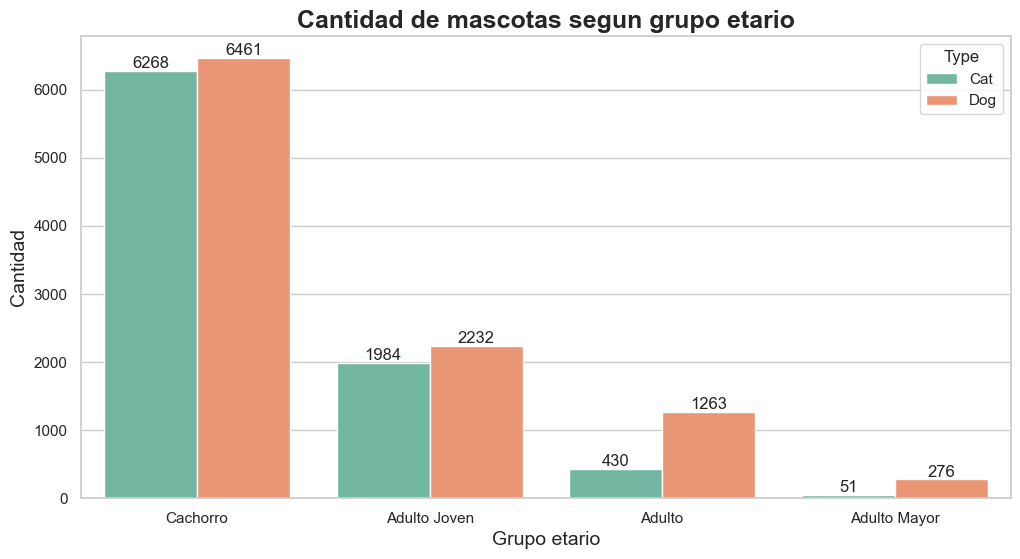

In [295]:
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(12,6))
ax = sns.countplot(
    x='Age_group',
    hue='Type',
    palette="Set2",
    data=all_data
)

# Etiquetas de conteo arriba de cada barra
for container in ax.containers:
    ax.bar_label(container)

# Títulos y ejes
ax.set_title("Cantidad de mascotas segun grupo etario", fontsize=18, weight='bold')
ax.set_xlabel("Grupo etario", fontsize=14)
ax.set_ylabel("Cantidad", fontsize=14)
ax.set_xticks(range(4))  
ax.set_xticklabels(['Cachorro', 'Adulto Joven', 'Adulto', 'Adulto Mayor'])

plt.show()

## Velocidad de adopción según grupo etario

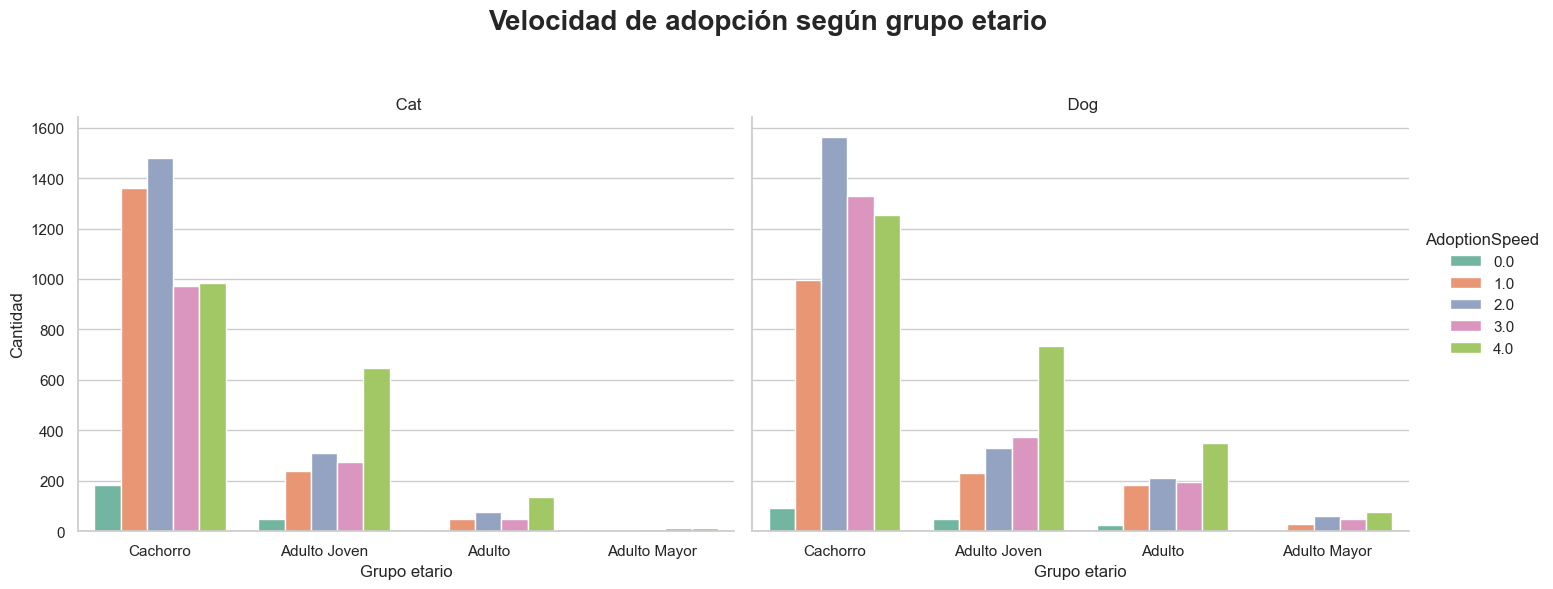

In [296]:
sns.set_theme(style="whitegrid")

g = sns.catplot(
    data=all_data,
    x="Age_group",
    hue="AdoptionSpeed",
    col="Type",            # separa en dos gráficos: Dogs y Cats
    kind="count",
    palette="Set2",
    height=6, aspect=1.2
)

# Renombrar etiquetas del eje X
labels = ['Cachorro', 'Adulto Joven', 'Adulto', 'Adulto Mayor']
for ax in g.axes.flat:
    ax.set_xticks(range(4))
    ax.set_xticklabels(labels)
    ax.set_xlabel("Grupo etario")
    ax.set_ylabel("Cantidad")
    ax.set_title(f"{ax.get_title().split('=')[-1]}")

plt.subplots_adjust(top=0.8)
g.figure.suptitle("Velocidad de adopción según grupo etario", fontsize=20, weight="bold")
plt.show()

## La raza de las mascotas influye en la velocidad de adopción ?

In [297]:
# Raza
all_data['Raza_pura'] = np.where(
    (all_data['Breed1'] != 307) & (all_data['Breed2'] == 0), 1, 0
)


In [298]:
# Agregar columna de raza al DataFrame
# Reemplazar Breed1 y Breed2 por sus nombres
breed_dict = dict(zip(raza['BreedID'], raza['BreedName']))
all_data['Breed1'] = all_data['Breed1'].map(breed_dict)
all_data['Breed2'] = all_data['Breed2'].map(breed_dict).fillna('No mix')


all_data.head()

,Type,Name,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,FurLength,Vaccinated,Dewormed,Sterilized,Health,Quantity,Fee,State,RescuerID,VideoAmt,Description,PetID,PhotoAmt,AdoptionSpeed,dataset_type,Has_name,Age_group,Raza_pura
0,Cat,Nibble,3,Tabby,No mix,1,1,7,0,1,1,2,2,2,1,1,100,41326,8480853f516546f6cf33aa88cd76c379,0,Nibble is a 3+ month old ball of cuteness. He ...,86e1089a3,1.0,2.0,train,1,1,1
1,Cat,No Name Yet,1,Domestic Medium Hair,No mix,1,1,2,0,2,2,3,3,3,1,1,0,41401,3082c7125d8fb66f7dd4bff4192c8b14,0,I just found it alone yesterday near my apartm...,6296e909a,2.0,0.0,train,0,1,1
2,Dog,Brisco,1,Mixed Breed,No mix,1,2,7,0,2,2,1,1,2,1,1,0,41326,fa90fa5b1ee11c86938398b60abc32cb,0,Their pregnant mother was dumped by her irresp...,3422e4906,7.0,3.0,train,1,1,0
3,Dog,Miko,4,Mixed Breed,No mix,2,1,2,0,2,1,1,1,2,1,1,150,41401,9238e4f44c71a75282e62f7136c6b240,0,"Good guard dog, very alert, active, obedience ...",5842f1ff5,8.0,2.0,train,1,1,0
4,Dog,Hunter,1,Mixed Breed,No mix,1,1,0,0,2,1,2,2,2,1,1,0,41326,95481e953f8aed9ec3d16fc4509537e8,0,This handsome yet cute boy is up for adoption....,850a43f90,3.0,2.0,train,1,1,0


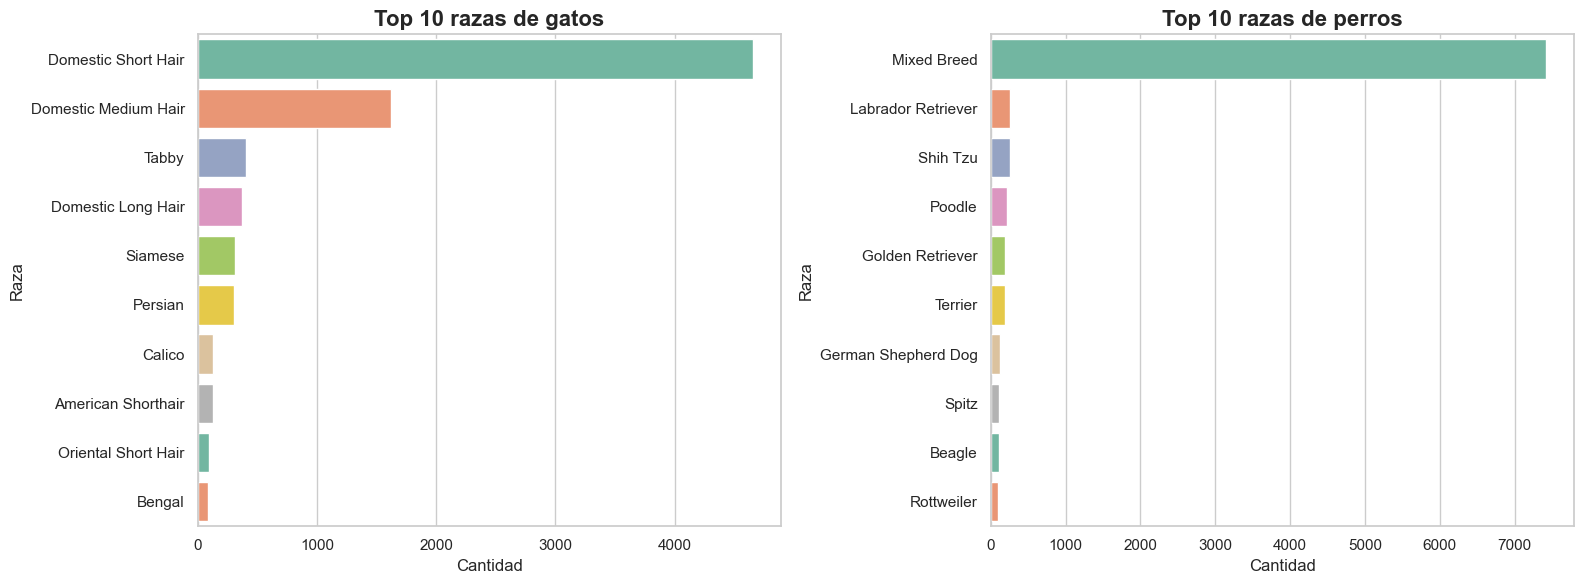

In [299]:
# Filtrar por especie
cats = all_data[all_data["Type"] == 'Cat']
dogs = all_data[all_data["Type"] == 'Dog']

# Top 10 razas
top_cats = cats["Breed1"].value_counts().nlargest(10)
top_dogs = dogs["Breed1"].value_counts().nlargest(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=False)

# --- Gatos ---
sns.barplot(
    y=top_cats.index,
    x=top_cats.values,
    hue= top_cats.index,
    palette="Set2",
    order=top_cats.index,
    ax=axes[0]
)
axes[0].set_title("Top 10 razas de gatos", fontsize=16, weight="bold")
axes[0].set_xlabel("Cantidad", fontsize=12)
axes[0].set_ylabel("Raza", fontsize=12)

# --- Perros ---
sns.barplot(
    y=top_dogs.index,
    x=top_dogs.values,
    hue= top_dogs.index,
    palette="Set2",
    order=top_dogs.index,
    ax=axes[1]
)
axes[1].set_title("Top 10 razas de perros", fontsize=16, weight="bold")
axes[1].set_xlabel("Cantidad", fontsize=12)
axes[1].set_ylabel("Raza", fontsize=12)

plt.tight_layout()
plt.show()


In [300]:
prop = (
    all_data
    .dropna(subset=["AdoptionSpeed"])
    .groupby(["Type","Raza_pura","AdoptionSpeed"])
    .size()
    .reset_index(name="count")
)

# Calcular proporción dentro de cada grupo (Type + Raza_pura)
prop["proporcion"] = prop.groupby(["Type","Raza_pura"])["count"].transform(lambda x: x / x.sum())

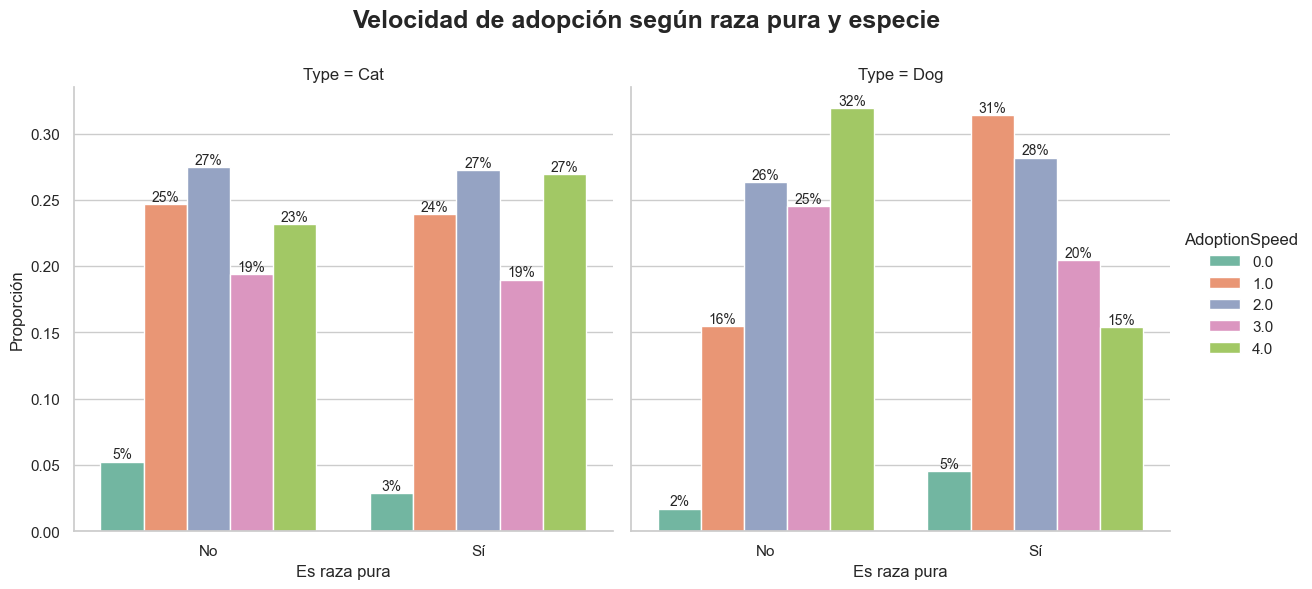

In [301]:
sns.set_theme(style="whitegrid")

g = sns.catplot(
    data=prop,
    x="Raza_pura",
    y="proporcion",
    hue="AdoptionSpeed",
    col="Type",              
    kind="bar",
    palette="Set2",
    height=6,
    aspect=1
)

# Ajustar títulos y etiquetas
labels = ["No", "Sí"]
for ax in g.axes.flat:
    ax.set_xticks([0,1])
    ax.set_xticklabels(labels)
    ax.set_xlabel("Es raza pura", fontsize=12)
    ax.set_ylabel("Proporción", fontsize=12)

# Etiquetas de porcentaje arriba de cada barra
for ax in g.axes.flat:
    for container in ax.containers:
        ax.bar_label(
            container,
            labels=[f"{v.get_height()*100:.0f}%" for v in container],
            label_type="edge",
            fontsize=10
        )

g.figure.suptitle("Velocidad de adopción según raza pura y especie", fontsize=18, weight="bold")
plt.subplots_adjust(top=0.85)


plt.show()

## Género de las mascotas

In [302]:
# Género de las mascotas
gender_map = {1: "Macho", 2: "Hembra", 3: "Mezcla"}
all_data["Gender_str"] = all_data["Gender"].map(gender_map)

all_data.head()

,Type,Name,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,FurLength,Vaccinated,Dewormed,Sterilized,Health,Quantity,Fee,State,RescuerID,VideoAmt,Description,PetID,PhotoAmt,AdoptionSpeed,dataset_type,Has_name,Age_group,Raza_pura,Gender_str
0,Cat,Nibble,3,Tabby,No mix,1,1,7,0,1,1,2,2,2,1,1,100,41326,8480853f516546f6cf33aa88cd76c379,0,Nibble is a 3+ month old ball of cuteness. He ...,86e1089a3,1.0,2.0,train,1,1,1,Macho
1,Cat,No Name Yet,1,Domestic Medium Hair,No mix,1,1,2,0,2,2,3,3,3,1,1,0,41401,3082c7125d8fb66f7dd4bff4192c8b14,0,I just found it alone yesterday near my apartm...,6296e909a,2.0,0.0,train,0,1,1,Macho
2,Dog,Brisco,1,Mixed Breed,No mix,1,2,7,0,2,2,1,1,2,1,1,0,41326,fa90fa5b1ee11c86938398b60abc32cb,0,Their pregnant mother was dumped by her irresp...,3422e4906,7.0,3.0,train,1,1,0,Macho
3,Dog,Miko,4,Mixed Breed,No mix,2,1,2,0,2,1,1,1,2,1,1,150,41401,9238e4f44c71a75282e62f7136c6b240,0,"Good guard dog, very alert, active, obedience ...",5842f1ff5,8.0,2.0,train,1,1,0,Hembra
4,Dog,Hunter,1,Mixed Breed,No mix,1,1,0,0,2,1,2,2,2,1,1,0,41326,95481e953f8aed9ec3d16fc4509537e8,0,This handsome yet cute boy is up for adoption....,850a43f90,3.0,2.0,train,1,1,0,Macho


In [303]:
# Cantidad de mascotas por género
gender_counts = all_data["Gender_str"].value_counts()
gender_counts


Gender_str
Hembra    9155
Macho     7040
Mezcla    2770
Name: count, dtype: int64

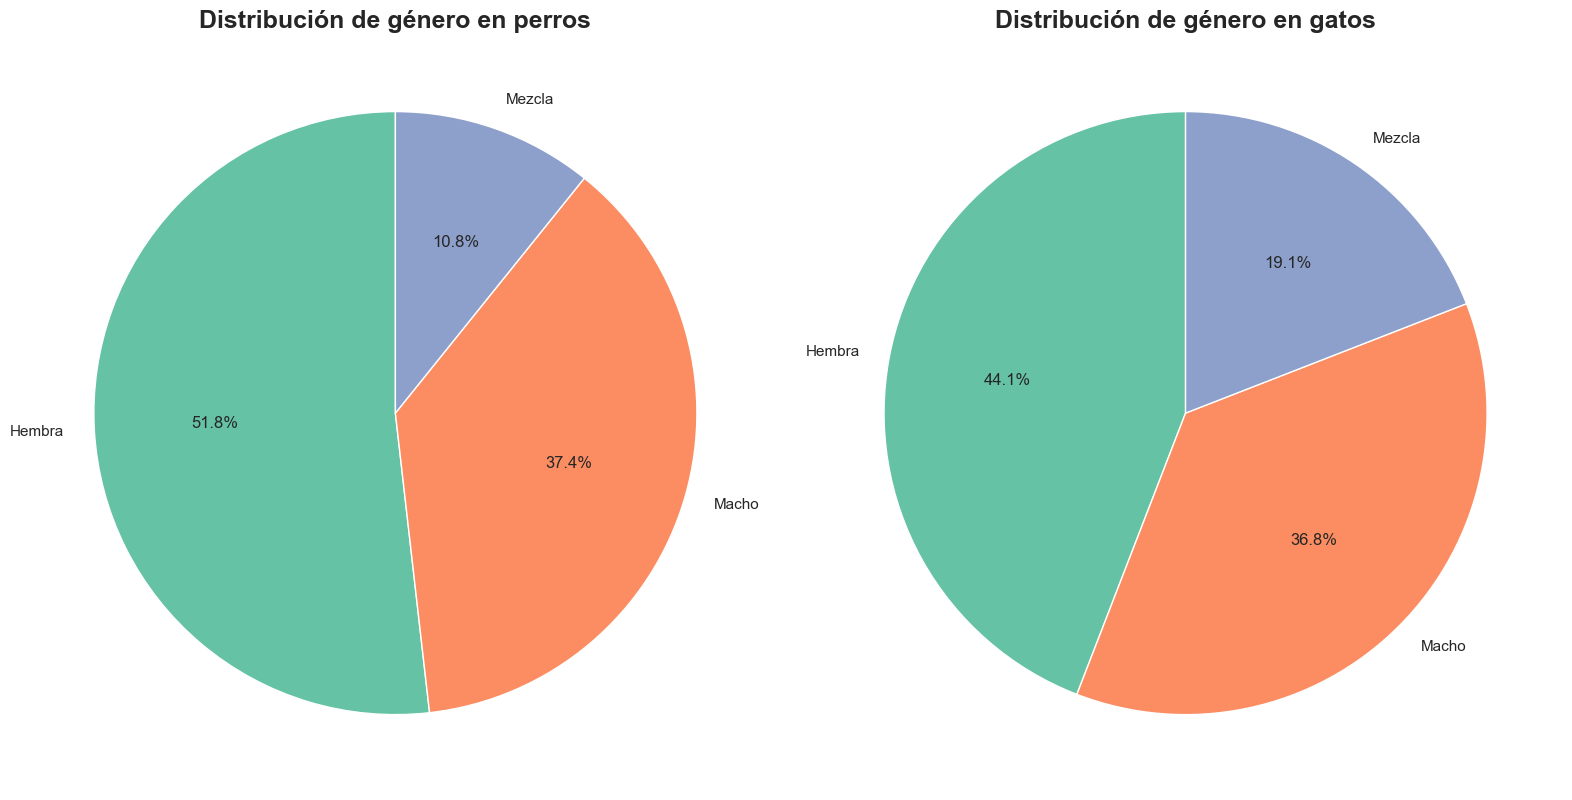

In [374]:
# Grafico de torta con genero segun perro y gato
# Pie chart por género y especie
fig, axs = plt.subplots(1, 2, figsize=(16, 8))
# Perros
dogs_gender_counts = all_data[all_data['Type'] == 'Dog']['Gender_str'].value_counts()
dogs_gender_counts.plot.pie(
    labels=dogs_gender_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    ax=axs[0],
    colors=sns.color_palette("Set2", n_colors=len(dogs_gender_counts))
)
axs[0].set_title("Distribución de género en perros", fontsize=18, weight="bold")
axs[0].set_ylabel("")

# Gatos
cats_gender_counts = all_data[all_data['Type'] == 'Cat']['Gender_str'].value_counts()
cats_gender_counts.plot.pie(
    labels=cats_gender_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    ax=axs[1],
    colors=sns.color_palette("Set2", n_colors=len(cats_gender_counts))
)
axs[1].set_title("Distribución de género en gatos", fontsize=18, weight="bold")
axs[1].set_ylabel("")

plt.tight_layout()
plt.show()

In [305]:
# Agrupar y contar
prop_gender = (
    all_data
    .dropna(subset=["AdoptionSpeed"])
    .groupby(["Gender_str","AdoptionSpeed"])
    .size()
    .reset_index(name="count")
)

# Calcular proporciones dentro de cada género
prop_gender["proporcion"] = prop_gender.groupby("Gender_str")["count"].transform(lambda x: x / x.sum())

## Velocidad de adopción según genero

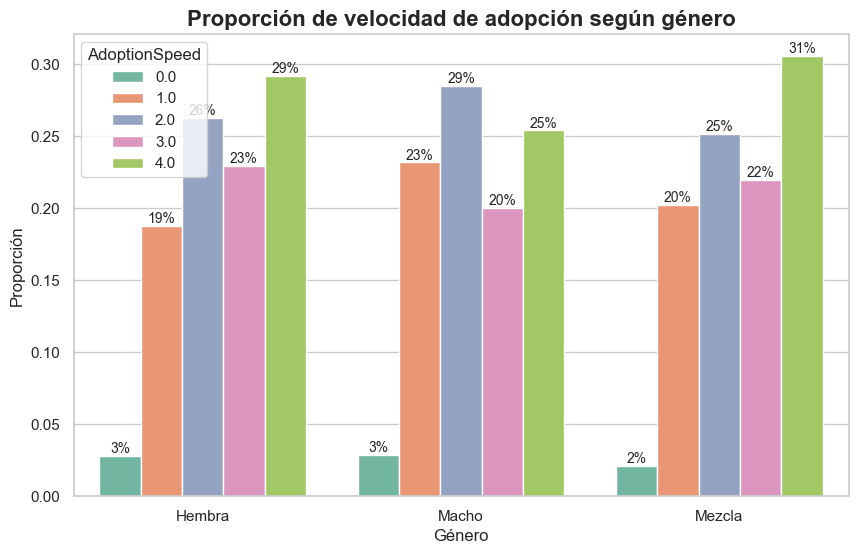

In [306]:
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(10,6))
sns.barplot(
    data=prop_gender,
    x="Gender_str",
    y="proporcion",
    hue="AdoptionSpeed",
    palette="Set2",
    ax=ax
)

# Etiquetas de porcentaje encima de cada barra
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f"{v.get_height()*100:.0f}%" for v in container],
        label_type="edge",
        fontsize=10
    )

ax.set_title("Proporción de velocidad de adopción según género", fontsize=16, weight="bold")
ax.set_xlabel("Género", fontsize=12)
ax.set_ylabel("Proporción", fontsize=12)

plt.legend(title="AdoptionSpeed")
plt.show()

## Proporción de velocidad de adopción según género en perros y gatos


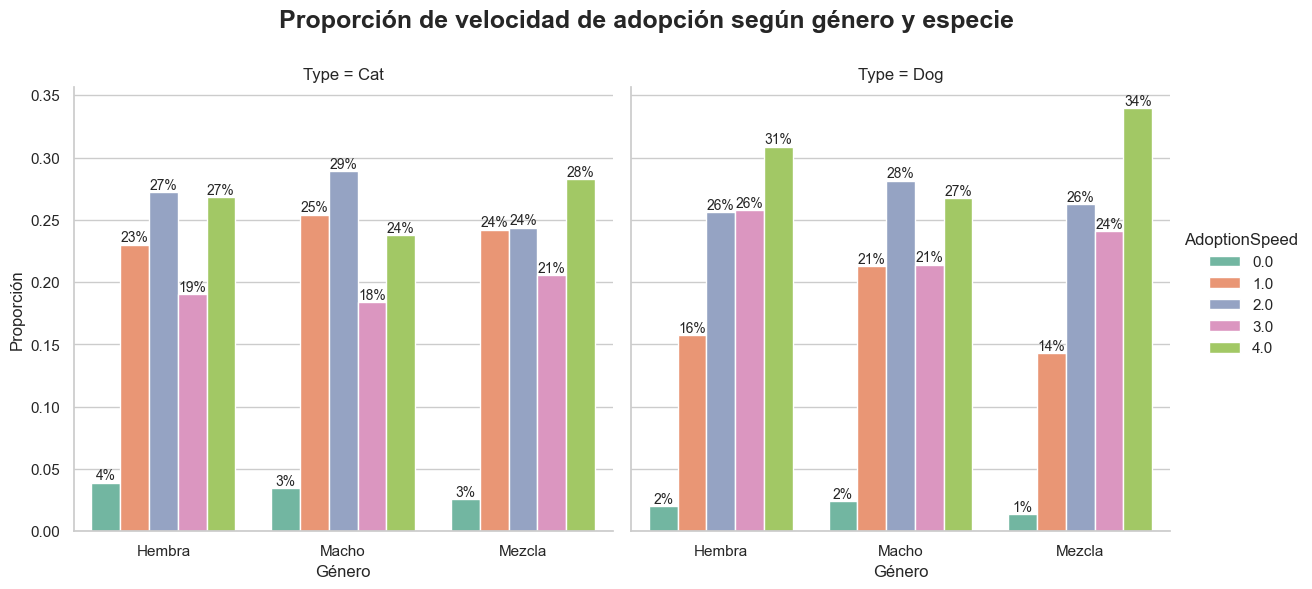

In [307]:
# Proporción de velocidad de adopción según género en perros y gatos

prop_gender_type = (
    all_data
    .dropna(subset=["AdoptionSpeed"])
    .groupby(["Type", "Gender_str", "AdoptionSpeed"])
    .size()
    .reset_index(name="count")
)

# Calcular proporciones dentro de cada grupo (Type + Gender_str)
prop_gender_type["proporcion"] = prop_gender_type.groupby(["Type", "Gender_str"])["count"].transform(lambda x: x / x.sum())

sns.set_theme(style="whitegrid")
g = sns.catplot(
    data=prop_gender_type,
    x="Gender_str",
    y="proporcion",
    hue="AdoptionSpeed",
    col="Type",
    kind="bar",
    palette="Set2",
    height=6,
    aspect=1
)

for ax in g.axes.flat:
    for container in ax.containers:
        ax.bar_label(
            container,
            labels=[f"{v.get_height()*100:.0f}%" for v in container],
            label_type="edge",
            fontsize=10
        )
    ax.set_xlabel("Género", fontsize=12)
    ax.set_ylabel("Proporción", fontsize=12)

g.figure.suptitle("Proporción de velocidad de adopción según género y especie", fontsize=18, weight="bold")
plt.subplots_adjust(top=0.85)
plt.show()


Los machos suelen adoptarse mas rapido que las hembras, especialmente en perros. En los gatos se ve menor diferencia en la velocidad de adopción entre machos y hembras.

## Salud de las mascotas

Dada por si estan vacunados, desparacitados y esterilizados


In [308]:
# Score de salud 
all_data['Cuidado_Medico'] = (
    (all_data['Vaccinated'] == 1).astype(int) +
    (all_data['Dewormed'] == 1).astype(int) +
    (all_data['Sterilized'] == 1).astype(int)
)

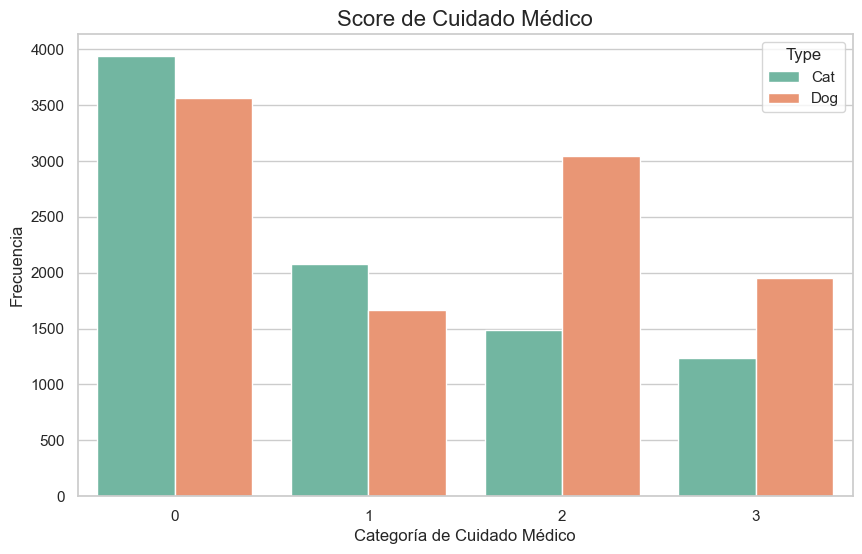

In [309]:
# Grafico de las categorias de Cuidado Medico 

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.countplot(data=all_data, 
              x='Cuidado_Medico', 
              hue='Type',
              palette='Set2')
plt.title("Score de Cuidado Médico", fontsize=16)
plt.xlabel("Categoría de Cuidado Médico", fontsize=12)
plt.ylabel("Frecuencia", fontsize=12)
plt.show()


## Desglozado por categoría

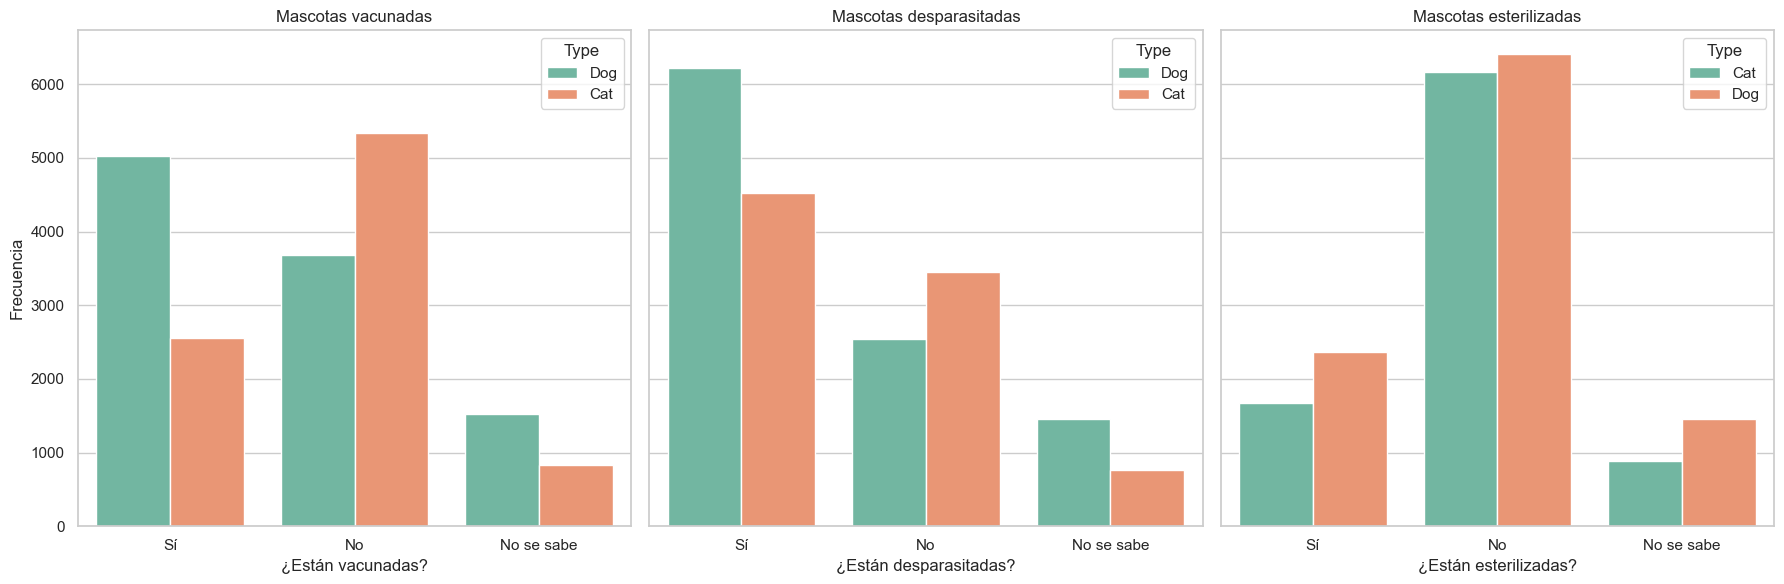

In [369]:

sns.set_theme(style="whitegrid")

labels = ["Sí", "No", "No se sabe"]

fig, axes = plt.subplots(1, 3, figsize=(18,6), sharey=True)

# --- Vaccinated ---
ax = sns.countplot(data=all_data, x="Vaccinated", hue="Type", palette="Set2", ax=axes[0])
ax.set_title("Mascotas vacunadas")
ax.set_xlabel("¿Están vacunadas?")
ax.set_ylabel("Frecuencia")
ax.set_xticks([0,1,2])
ax.set_xticklabels(labels)

# --- Dewormed ---
ax = sns.countplot(data=all_data, x="Dewormed", hue="Type", palette="Set2", ax=axes[1])
ax.set_title("Mascotas desparasitadas")
ax.set_xlabel("¿Están desparasitadas?")
ax.set_ylabel("")
ax.set_xticks([0,1,2])
ax.set_xticklabels(labels)

# --- Sterilized ---
ax = sns.countplot(data=all_data, x="Sterilized", hue="Type", palette="Set2", ax=axes[2])
ax.set_title("Mascotas esterilizadas")
ax.set_xlabel("¿Están esterilizadas?")
ax.set_ylabel("")
ax.set_xticks([0,1,2])
ax.set_xticklabels(labels)

plt.tight_layout()
plt.show()

## Velocidad de adopción según si están vacunados o no.

In [335]:
import matplotlib.ticker as mtick

# 5 categorías de AdoptionSpeed (0–4)
cols = sns.color_palette("Set2", 5)

sns.set_theme(style="whitegrid")
df = all_data.dropna(subset=["AdoptionSpeed"]).copy()
df["Type_str"] = df["Type"].map({1:"Cat", 2:"Dog"}).fillna(df["Type"])
labels_ynm = {1:"Sí", 2:"No", 3:"No se sabe"}
order_ynm  = [1,2,3]
order_adopt = [0,1,2,3,4]
cols = sns.color_palette("Set2", 5)  # 5 clases de AdoptionSpeed

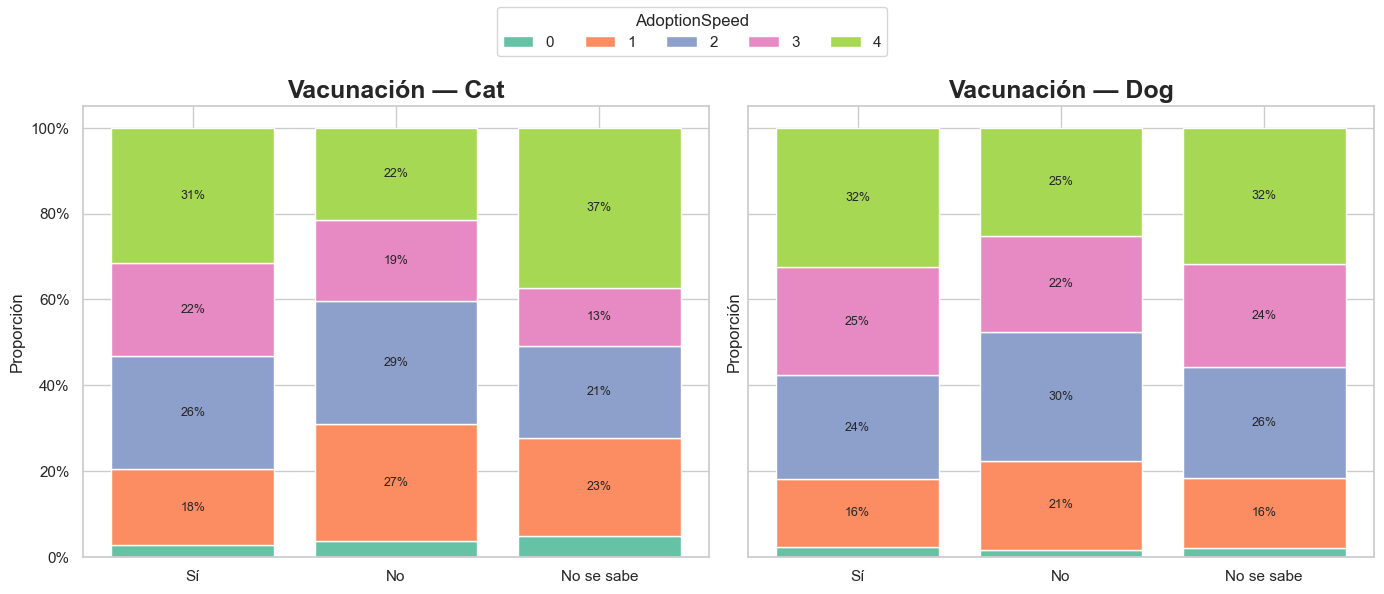

In [339]:
# tabla de proporciones por especie y categoría (Sí/No/No se sabe)
t = (df.groupby(["Type_str","Vaccinated","AdoptionSpeed"])
        .size().reset_index(name="count"))
t["prop"] = t.groupby(["Type_str","Vaccinated"])["count"].transform(lambda x: x/x.sum())

# pivot por especie
pv = (t.pivot_table(index=["Type_str","Vaccinated"], columns="AdoptionSpeed",
                    values="prop", fill_value=0)
        .reindex(columns=order_adopt))

fig, axes = plt.subplots(1, 2, figsize=(14,6), sharey=True)
for ax, specie in zip(axes, ["Cat","Dog"]):
    sub = (pv.loc[specie] if specie in pv.index.get_level_values(0) else
           pd.DataFrame(0, index=pd.Index(order_ynm, name="Vaccinated"), columns=order_adopt))
    sub = sub.reindex(index=order_ynm, fill_value=0)
    x = np.arange(len(sub))
    bottom = np.zeros(len(sub))
    for i, cls in enumerate(order_adopt):
        vals = sub[cls].values
        bars = ax.bar(x, vals, bottom=bottom, label=str(cls), color=cols[i])
        bottom += vals
        # etiquetas dentro del segmento si >=5%
        for b, v in zip(bars, vals):
            if v >= 0.05:
                ax.text(b.get_x()+b.get_width()/2, b.get_y()+v/2, f"{v*100:.0f}%",
                        ha="center", va="center", fontsize=9)

    ax.set_xticks(x)
    ax.set_xticklabels([labels_ynm[i] for i in order_ynm])
    ax.set_title(f"Vacunación — {specie}", fontsize=18, weight="bold")
    ax.set_ylabel("Proporción")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="AdoptionSpeed", loc="upper center", ncol=5)
plt.tight_layout(rect=[0,0,1,0.9])
plt.show()

## Velocidad de adopción según si están desparasitados o no.

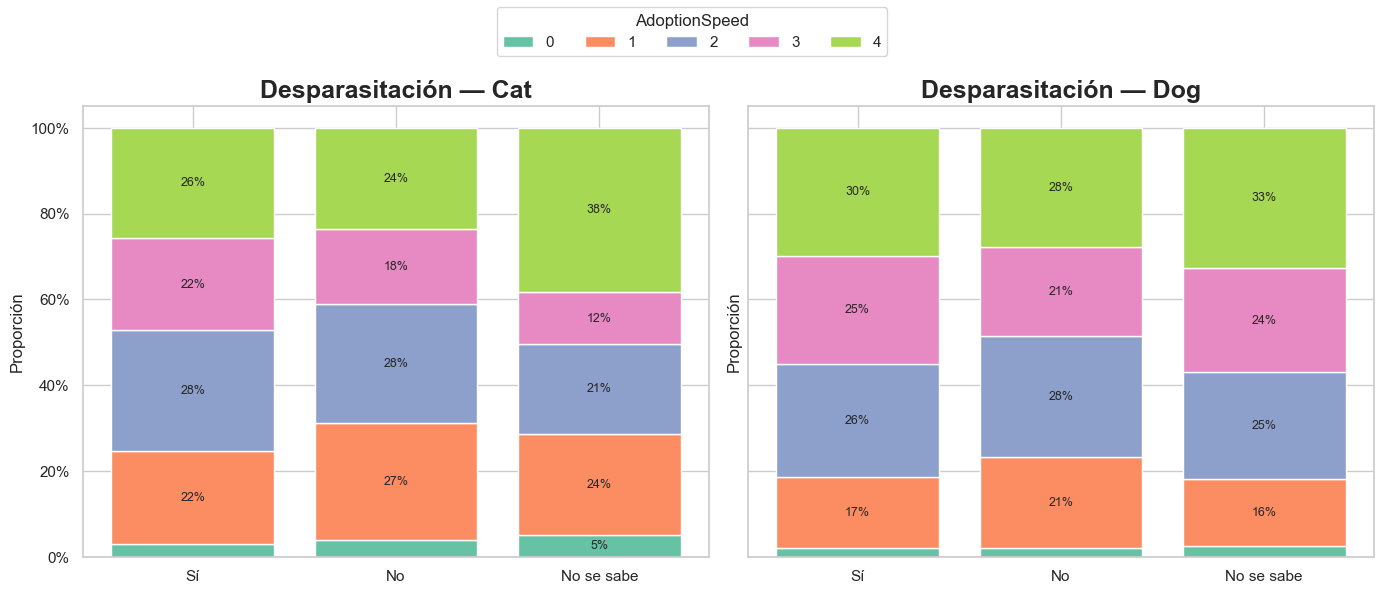

In [340]:
t = (df.groupby(["Type_str","Dewormed","AdoptionSpeed"])
        .size().reset_index(name="count"))
t["prop"] = t.groupby(["Type_str","Dewormed"])["count"].transform(lambda x: x/x.sum())
pv = (t.pivot_table(index=["Type_str","Dewormed"], columns="AdoptionSpeed",
                    values="prop", fill_value=0)
        .reindex(columns=order_adopt))

fig, axes = plt.subplots(1, 2, figsize=(14,6), sharey=True)
for ax, specie in zip(axes, ["Cat","Dog"]):
    sub = (pv.loc[specie] if specie in pv.index.get_level_values(0) else
           pd.DataFrame(0, index=pd.Index(order_ynm, name="Dewormed"), columns=order_adopt))
    sub = sub.reindex(index=order_ynm, fill_value=0)
    x = np.arange(len(sub)); bottom = np.zeros(len(sub))
    for i, cls in enumerate(order_adopt):
        vals = sub[cls].values
        bars = ax.bar(x, vals, bottom=bottom, label=str(cls), color=cols[i])
        bottom += vals
        for b, v in zip(bars, vals):
            if v >= 0.05:
                ax.text(b.get_x()+b.get_width()/2, b.get_y()+v/2, f"{v*100:.0f}%",
                        ha="center", va="center", fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels([labels_ynm[i] for i in order_ynm])
    ax.set_title(f"Desparasitación — {specie}", fontsize=18, weight="bold")
    ax.set_ylabel("Proporción")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="AdoptionSpeed", loc="upper center", ncol=5)
plt.tight_layout(rect=[0,0,1,0.9])
plt.show()

## Velocidad de adopción según si están esterilizados o no.

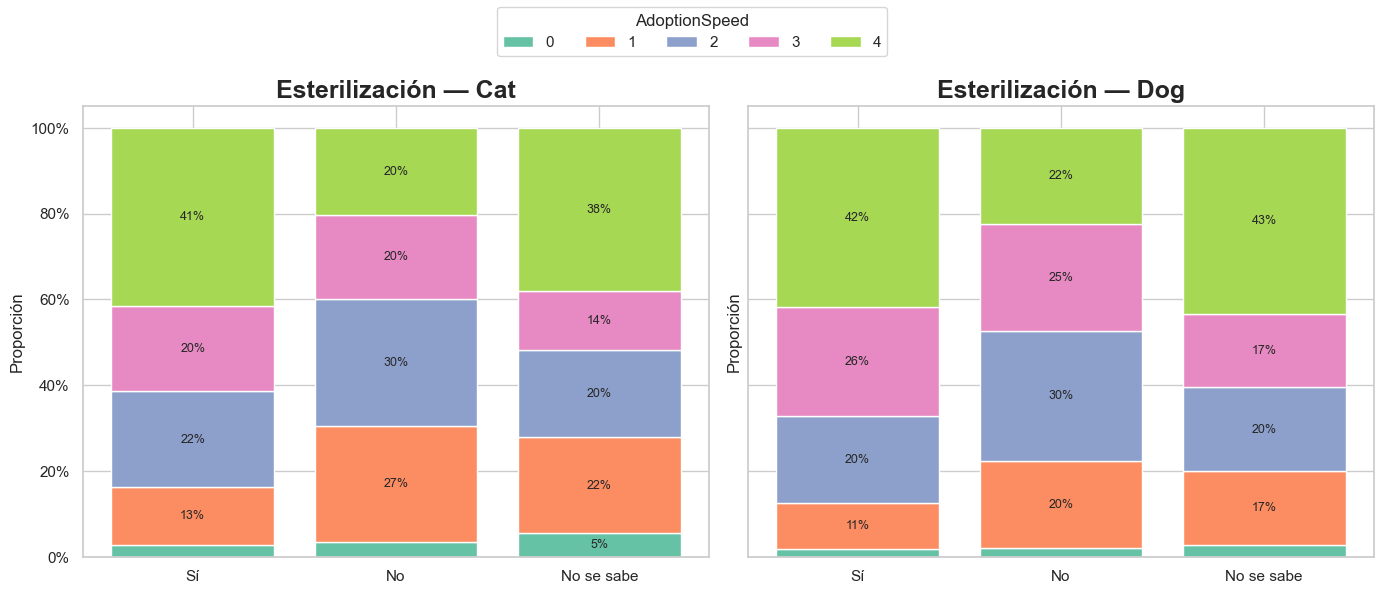

In [362]:
# tabla de proporciones por especie y categoría (Sí/No/No se sabe)
t = (df.groupby(["Type_str","Sterilized","AdoptionSpeed"])
        .size().reset_index(name="count"))
t["prop"] = t.groupby(["Type_str","Sterilized"])["count"].transform(lambda x: x/x.sum())

# pivot por especie
pv = (t.pivot_table(index=["Type_str","Sterilized"], columns="AdoptionSpeed",
                    values="prop", fill_value=0)
        .reindex(columns=order_adopt))

fig, axes = plt.subplots(1, 2, figsize=(14,6), sharey=True)
for ax, specie in zip(axes, ["Cat","Dog"]):
    sub = (pv.loc[specie] if specie in pv.index.get_level_values(0) else
           pd.DataFrame(0, index=pd.Index(order_ynm, name="Sterilized"), columns=order_adopt))
    sub = sub.reindex(index=order_ynm, fill_value=0)
    x = np.arange(len(sub))
    bottom = np.zeros(len(sub))
    for i, cls in enumerate(order_adopt):
        vals = sub[cls].values
        bars = ax.bar(x, vals, bottom=bottom, label=str(cls), color=cols[i])
        bottom += vals
        # etiquetas dentro del segmento si >=5%
        for b, v in zip(bars, vals):
            if v >= 0.05:
                ax.text(b.get_x()+b.get_width()/2, b.get_y()+v/2, f"{v*100:.0f}%",
                        ha="center", va="center", fontsize=9)

    ax.set_xticks(x)
    ax.set_xticklabels([labels_ynm[i] for i in order_ynm])
    ax.set_title(f"Esterilización — {specie}", fontsize=18, weight="bold")
    ax.set_ylabel("Proporción")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="AdoptionSpeed", loc="upper center", ncol=5)
plt.tight_layout(rect=[0,0,1,0.9])
plt.show()

## Condición de salud

Variable: Health - Health Condition (1 = Healthy, 2 = Minor Injury, 3 = Serious Injury, 0 = Not Specified)

In [380]:
labels = {1:"Saludable", 2:"Lesión menor", 3:"Lesión grave", 0:"No especificado"}
all_data["Health_str"] = all_data["Health"].map(labels)


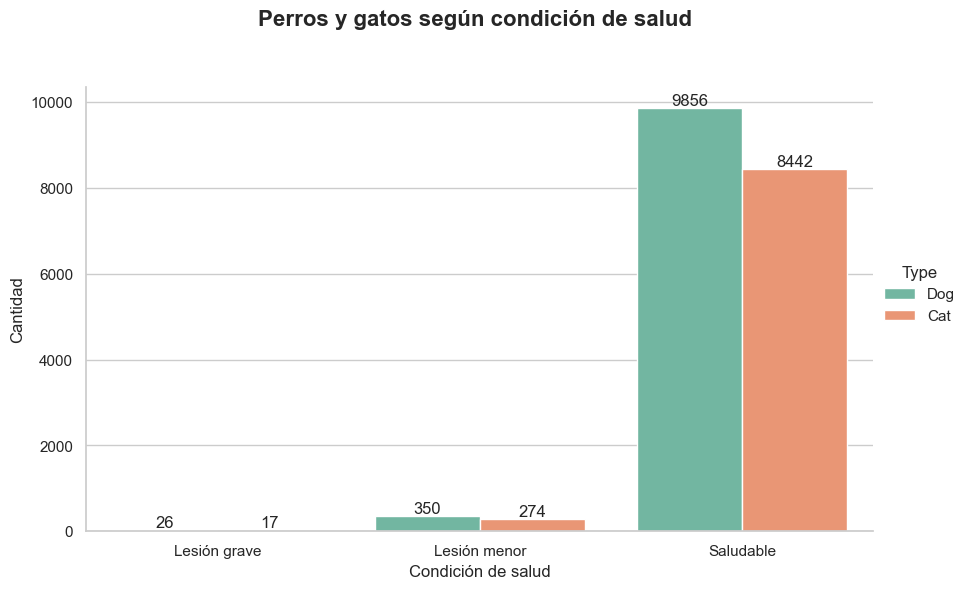

In [381]:
# Perros y gatos segun condicion de salud

sns.set_theme(style="whitegrid")

# Luego graficás con esa columna
df_health = (
    all_data.dropna(subset=["Health_str", "Type"])
    .groupby(["Health_str", "Type"])
    .size()
    .reset_index(name="count")
)

g = sns.catplot(
    data=df_health,
    x="Health_str", y="count",
    hue="Type", hue_order=["Dog", "Cat"],
    kind="bar", palette="Set2",
    height=6, aspect=1.5
)

for ax in g.axes.flat:
    ax.set_xlabel("Condición de salud")
    ax.set_ylabel("Cantidad")
    for cont in ax.containers:
        ax.bar_label(cont, labels=[f"{b.get_height():.0f}" for b in cont], label_type="edge")

g.figure.suptitle("Perros y gatos según condición de salud", fontsize=16, weight="bold")
plt.subplots_adjust(top=0.85)
plt.show()


## Velocidad de adopción según condición de salud

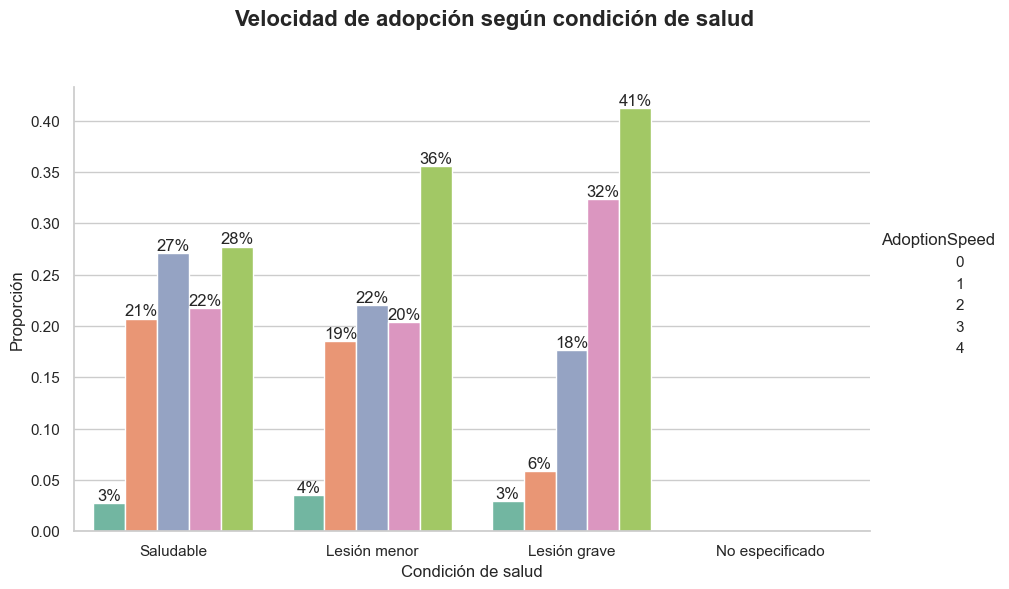

In [383]:
# Tabla de proporciones
df_health = (
    all_data.dropna(subset=["AdoptionSpeed"])
    .groupby(["Health_str", "AdoptionSpeed"])
    .size()
    .reset_index(name="count")
)
df_health["prop"] = df_health.groupby("Health_str")["count"].transform(lambda x: x/x.sum())

# Gráfico
g = sns.catplot(
    data=df_health,
    x="Health_str", y="prop",
    hue="AdoptionSpeed", hue_order=[0,1,2,3,4],
    kind="bar", palette="Set2",
    height=6, aspect=1.5,
    order=["Saludable", "Lesión menor", "Lesión grave", "No especificado"]
)

for ax in g.axes.flat:
    for cont in ax.containers:
        ax.bar_label(cont, labels=[f"{b.get_height()*100:.0f}%" for b in cont], label_type="edge")

g.set_axis_labels("Condición de salud", "Proporción")
g.fig.suptitle("Velocidad de adopción según condición de salud", fontsize=16, weight="bold")
plt.subplots_adjust(top=0.85)
plt.show()

## Relación entre Fee y velocidad de adopción

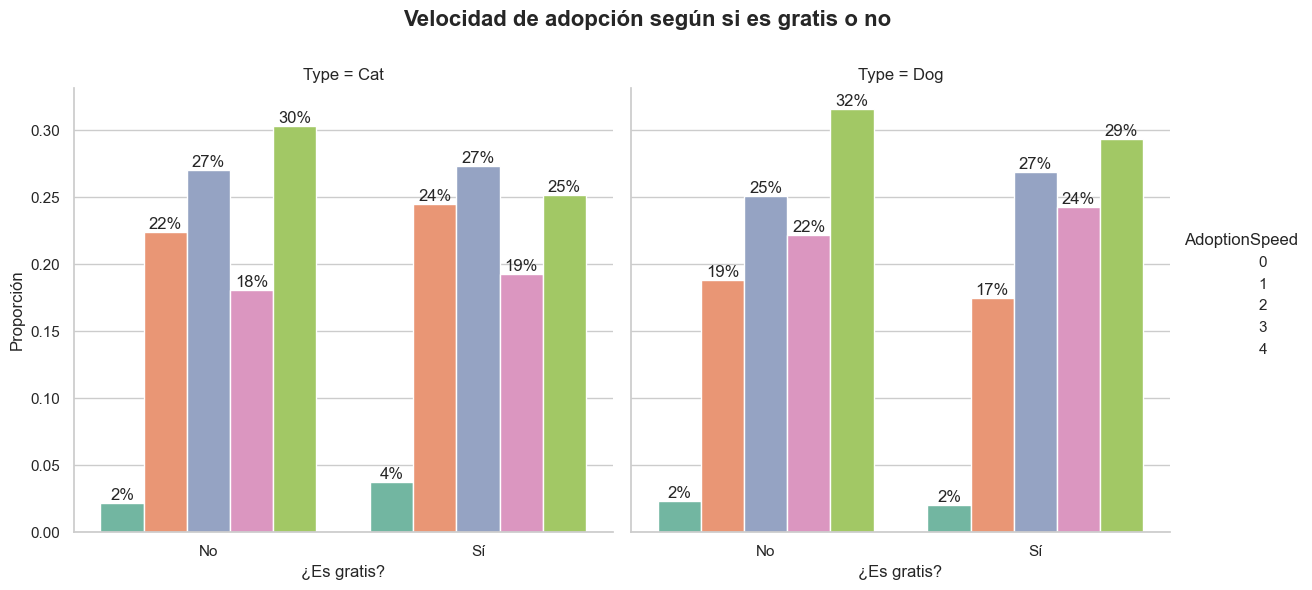

In [359]:
# Gratis o no
all_data["Gratis"] = all_data["Fee"].apply(lambda x: "Sí" if x==0 else "No")

#Velocidad de adopcion segun si es gratis o no, en perros y gatos
df_fee = (
    all_data.dropna(subset=["AdoptionSpeed"])
    .groupby(["Type", "Gratis", "AdoptionSpeed"])
    .size()
    .reset_index(name="count")
)
df_fee["prop"] = df_fee.groupby(["Type","Gratis"])["count"].transform(lambda x: x/x.sum())

# Gráfico
g = sns.catplot(
    data=df_fee,
    x="Gratis", y="prop",
    hue="AdoptionSpeed", hue_order=[0,1,2,3,4],
    col="Type",
    kind="bar", palette="Set2",
    height=6, aspect=1
)

for ax in g.axes.flat:
    ax.set_xlabel("¿Es gratis?")
    ax.set_ylabel("Proporción")
    for cont in ax.containers:
        ax.bar_label(cont, labels=[f"{b.get_height()*100:.0f}%" for b in cont], label_type="edge")

g.figure.suptitle("Velocidad de adopción según si es gratis o no", fontsize=16, weight="bold")
plt.subplots_adjust(top=0.85)
plt.show()

## Monto del fee y la velocidad de adopción

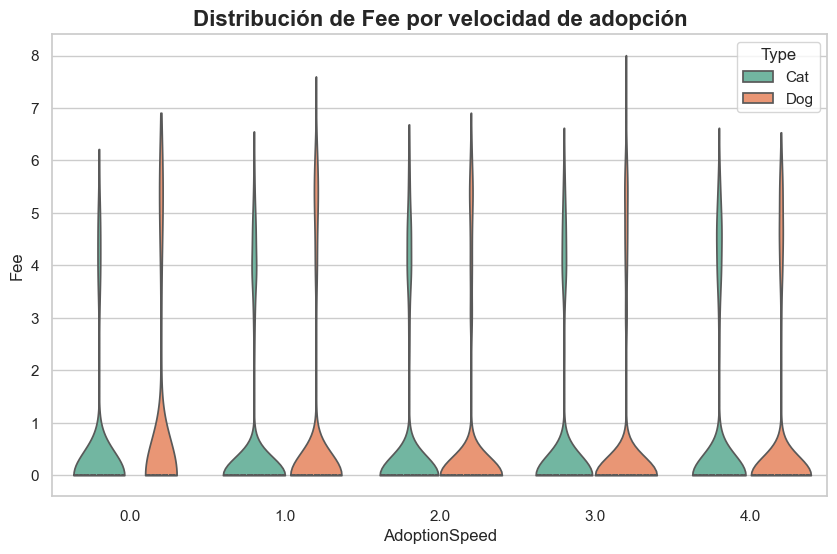

In [367]:
sns.set_theme(style="whitegrid")

df_plot = all_data.dropna(subset=["AdoptionSpeed", "Fee"]).copy()
df_plot["Fee_log1p"] = np.log1p(df_plot["Fee"])


fig, ax = plt.subplots(figsize=(10,6))
sns.violinplot(
    data=df_plot,
    x="AdoptionSpeed",
    hue="Type",
    y="Fee_log1p",
    inner="quartile",   # muestra Q1/mediana/Q3
    palette="Set2",
    cut=0,
    ax=ax
)

ax.set_title("Distribución de Fee por velocidad de adopción", fontsize=16, weight="bold")
ax.set_xlabel("AdoptionSpeed")
ax.set_ylabel("Fee")
plt.show()

## Cantidad de fotos vs Velocidad de adopción

In [372]:
# Cantidad de fotos. Mostrar algunas imagenes 
def clasificar_fotos(x):
    if x == 0:
        return "sin fotos"
    elif x <= 5:
        return "menos de 5"
    else:
        return "5 o más"

all_data['Fotos'] = all_data['PhotoAmt'].apply(clasificar_fotos)

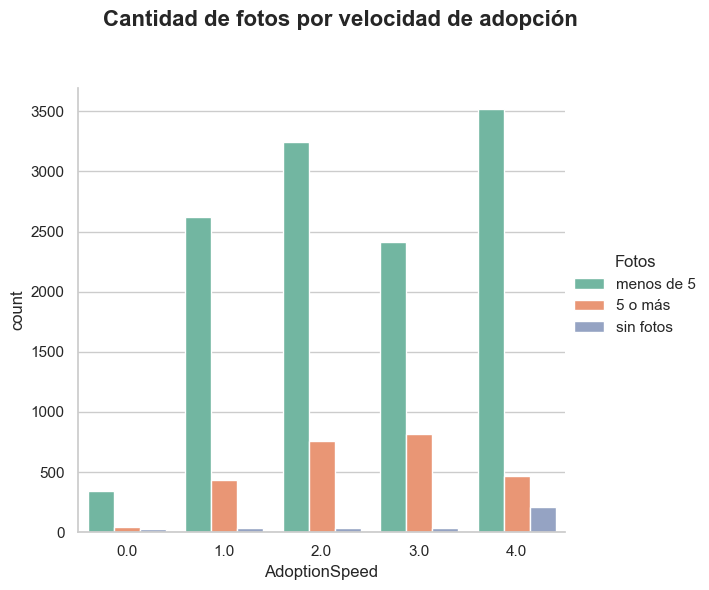

In [373]:
# Cantidad de fotos vs Velocidad de adopción
sns.set_theme(style="whitegrid")

df_plot = all_data.dropna(subset=["AdoptionSpeed", "Fotos"]).copy()

g = sns.catplot(
    data=df_plot, kind="count",
    x="AdoptionSpeed", hue="Fotos",
    palette="Set2", height=6, aspect=1
)
g.fig.suptitle("Cantidad de fotos por velocidad de adopción", fontsize=16, weight="bold")
plt.subplots_adjust(top=0.85)
plt.show()

## Tener videos impacta en la velocidad de adopción?

In [376]:
all_data["Video"] = all_data["VideoAmt"].apply(lambda x: "No" if x == 0 else "Sí")

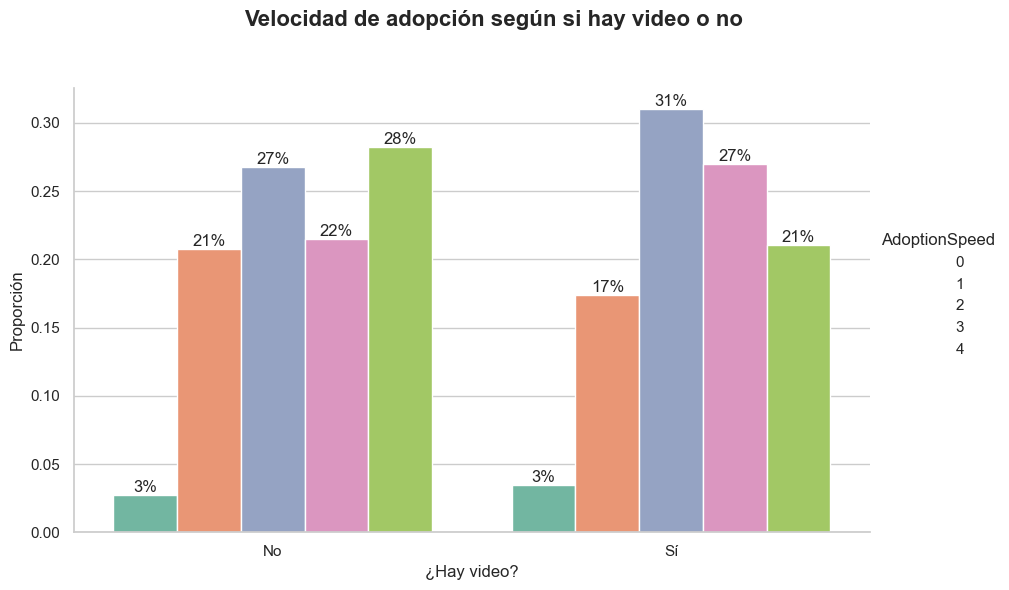

In [377]:
# Velocidad de adopción según si hay video o no

sns.set_theme(style="whitegrid")

df_video = (
    all_data.dropna(subset=["AdoptionSpeed"])
    .groupby(["Video", "AdoptionSpeed"])
    .size()
    .reset_index(name="count")
)
df_video["prop"] = df_video.groupby("Video")["count"].transform(lambda x: x/x.sum())

g = sns.catplot(
    data=df_video,
    x="Video", y="prop",
    hue="AdoptionSpeed", hue_order=[0,1,2,3,4],
    kind="bar", palette="Set2",
    height=6, aspect=1.5,
    order=["No", "Sí"]
)

for ax in g.axes.flat:
    ax.set_xlabel("¿Hay video?")
    ax.set_ylabel("Proporción")
    for cont in ax.containers:
        ax.bar_label(cont, labels=[f"{b.get_height()*100:.0f}%" for b in cont], label_type="edge")

g.figure.suptitle("Velocidad de adopción según si hay video o no", fontsize=16, weight="bold")
plt.subplots_adjust(top=0.85)
plt.show()
